# Pricing Simulation: A Hypothetical PTD/TTD Product

**Goal:** simulate a "book" of insured players under a hypothetical
disability insurance structure (attachment point + limit, like the real
TTD policies described in the Sportico/Rodgers reporting), and estimate
the distribution of aggregate losses -- the core Monte Carlo exercise real
pricing actuaries run before setting a premium.

**Inputs:**
- **Frequency**: the PTD and TTD logistic GLMs fitted in notebook 1
  (probability of each outcome, by position + age)
- **Severity**: empirical annual guaranteed-money-at-risk, bootstrap-
  sampled from real contract data matched to real claims (same logic as
  `sql/04_dollar_exposure_by_classification.sql`)

**Policy structure simulated:** attachment point (like a deductible) and a
limit (max payout per claim) -- the same structure real TTD/PTD policies
use.

In [1]:
%matplotlib inline
import sqlite3
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

DB_PATH = "../data/nfl_injury_project.db"
conn = sqlite3.connect(DB_PATH)

with open("fitted_models.pkl", "rb") as f:
    models = pickle.load(f)
model_ptd = models["ptd"]
model_ttd = models["ttd"]
print("Loaded fitted frequency models from notebook 1.")

Loaded fitted frequency models from notebook 1.


## 1. Pull the empirical severity distribution (dollar terms)

Same contract-matching logic as `sql/04` -- for each real claim, find the
guaranteed money at risk that season, expressed as an annualized figure
($M/year of the contract).

In [2]:
severity_query = '''
WITH ranked_contracts AS (
    SELECT
        c.position_group, c.player_id, c.season, c.claim_classification,
        ct.guaranteed, ct.years,
        ROW_NUMBER() OVER (
            PARTITION BY c.position_group, c.player_id, c.season
            ORDER BY ct.year_signed DESC
        ) AS rn
    FROM fact_claims c
    LEFT JOIN fact_contracts ct
        ON ct.player_id = c.player_id
        AND c.season >= ct.year_signed
        AND c.season < ct.year_signed + ct.years
    WHERE c.claim_classification IN ('PTD','TTD')
)
SELECT position_group, claim_classification, guaranteed*1.0/years AS annual_guaranteed_at_risk
FROM ranked_contracts
WHERE rn = 1 AND guaranteed IS NOT NULL
'''
severity = pd.read_sql(severity_query, conn)
severity.groupby(["position_group","claim_classification"])["annual_guaranteed_at_risk"].describe().round(2)

count  mean   std  min   25%   50%   75%  \
position_group claim_classification                                             
OL             PTD                   179.0  0.92  1.58  0.0  0.00  0.15  1.25   
               TTD                   179.0  1.77  2.70  0.0  0.12  0.60  2.52   
QB             PTD                    62.0  2.65  3.61  0.0  0.08  1.00  3.79   
               TTD                    33.0  5.82  4.36  0.0  2.84  4.75  8.79   
RB             PTD                   129.0  0.36  0.66  0.0  0.01  0.10  0.30   
               TTD                   113.0  0.91  1.53  0.0  0.03  0.17  1.28   

                                       max  
position_group claim_classification         
OL             PTD                    7.50  
               TTD                   18.04  
QB             PTD                   16.62  
               TTD                   15.75  
RB             PTD                    4.15  
               TTD                    7.52

## 2. The simulation function

For a given position and age:
1. Predict P(PTD) and P(TTD) from the fitted frequency GLMs
2. Simulate a book of `n_players` for `n_sims` iterations
3. For each simulated player, draw a claim outcome from the predicted
   probabilities; if a claim occurs, bootstrap-sample a dollar severity
   from the real empirical distribution for that position/classification
4. Apply the policy structure (attachment point, limit) to get the payout
5. Sum payouts across the book to get one simulated "aggregate annual
   loss" draw; repeat `n_sims` times to build a full distribution

In [3]:
def simulate_book(position, age, n_players=50, n_sims=10000, attachment=0.5, limit=5.0):
    X = pd.DataFrame({"position_group": [position], "age": [age]})
    p_ptd = model_ptd.predict(X).iloc[0]
    p_ttd = model_ttd.predict(X).iloc[0]
    p_none = 1 - p_ptd - p_ttd
    probs = [p_none, p_ptd, p_ttd]

    ptd_pool = severity[
        (severity.position_group == position) & (severity.claim_classification == "PTD")
    ]["annual_guaranteed_at_risk"].values
    ttd_pool = severity[
        (severity.position_group == position) & (severity.claim_classification == "TTD")
    ]["annual_guaranteed_at_risk"].values

    totals = np.zeros(n_sims)
    zero_payout_claims, total_claims = 0, 0
    for i in range(n_sims):
        outcomes = np.random.choice(["none", "PTD", "TTD"], size=n_players, p=probs)
        book_loss = 0.0
        for o in outcomes:
            if o == "PTD":
                loss = np.random.choice(ptd_pool)
            elif o == "TTD":
                loss = np.random.choice(ttd_pool)
            else:
                continue
            total_claims += 1
            payout = min(max(loss - attachment, 0), limit)
            if payout == 0:
                zero_payout_claims += 1
            book_loss += payout
        totals[i] = book_loss
    zero_pct = zero_payout_claims / total_claims if total_claims else None
    return probs, totals, zero_pct

print("Simulation function defined.")

Simulation function defined.


## 3. Run the simulation: a 50-player RB book, age 25

Policy structure: $0.5M attachment point, $5M limit per claim (illustrative
-- in the same order of magnitude as the real Rodgers TTD policy premiums
reported by Sportico, which ran $1-4M for ~60% coverage of a $37M salary).

In [4]:
probs, totals, _ = simulate_book("RB", age=25, n_players=50, n_sims=10000, attachment=0.5, limit=5.0)

print(f"P(no claim) = {probs[0]:.3f}, P(PTD) = {probs[1]:.3f}, P(TTD) = {probs[2]:.3f}")
print()
print(f"Mean aggregate annual loss (book of 50 RBs): ${totals.mean():.2f}M")
print(f"Std dev: ${totals.std():.2f}M")
print(f"P50 (median): ${np.percentile(totals, 50):.2f}M")
print(f"P95: ${np.percentile(totals, 95):.2f}M")
print(f"P99: ${np.percentile(totals, 99):.2f}M")

P(no claim) = 0.884, P(PTD) = 0.064, P(TTD) = 0.053

Mean aggregate annual loss (book of 50 RBs): $2.23M
Std dev: $2.37M
P50 (median): $1.66M
P95: $6.95M
P99: $9.96M


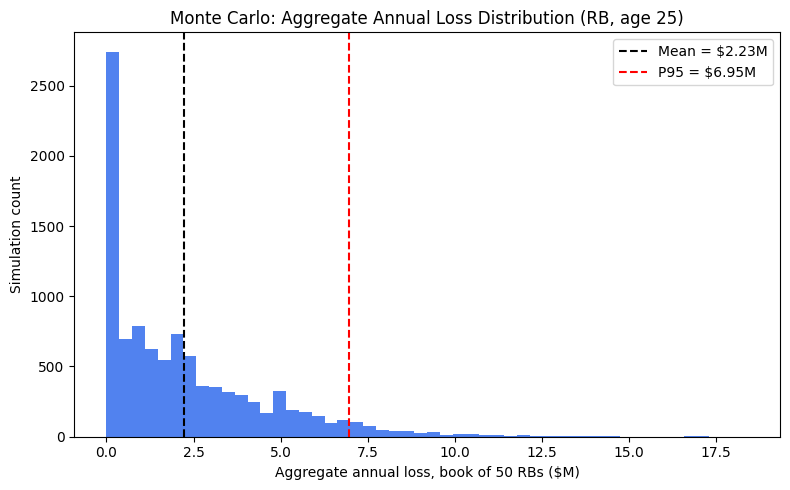

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(totals, bins=50, color="#2563eb", alpha=0.8)
ax.axvline(totals.mean(), color="black", linestyle="--", label=f"Mean = ${totals.mean():.2f}M")
ax.axvline(np.percentile(totals, 95), color="red", linestyle="--", label=f"P95 = ${np.percentile(totals,95):.2f}M")
ax.set_xlabel("Aggregate annual loss, book of 50 RBs ($M)")
ax.set_ylabel("Simulation count")
ax.set_title("Monte Carlo: Aggregate Annual Loss Distribution (RB, age 25)")
ax.legend()
plt.tight_layout()
plt.savefig("pricing_sim_rb25.png", dpi=120)
plt.show()

## 4. Compare across positions and ages

Running the same simulation for a few different position/age combinations
shows how the *pure premium per player* (mean aggregate loss / number of
players) scales -- the actual number a pricing memo would quote.

In [6]:
scenarios = [
    ("RB", 23), ("RB", 27), ("RB", 31),
    ("OL", 27), ("QB", 27),
]

rows = []
for pos, age in scenarios:
    probs, totals, _ = simulate_book(pos, age, n_players=50, n_sims=5000, attachment=0.5, limit=5.0)
    rows.append({
        "position": pos, "age": age,
        "p_ptd": probs[1], "p_ttd": probs[2],
        "mean_pure_premium_per_player_M": totals.mean() / 50,
        "p95_pure_premium_per_player_M": np.percentile(totals, 95) / 50,
    })

pd.DataFrame(rows).round(4)

,position,age,p_ptd,p_ttd,mean_pure_premium_per_player_M,p95_pure_premium_per_player_M
0,RB,23,0.0545,0.0559,0.0441,0.1431
1,RB,27,0.0745,0.0496,0.0445,0.1363
2,RB,31,0.1012,0.0440,0.0454,0.1399
3,OL,27,0.0348,0.0327,0.0605,0.1920
4,QB,27,0.0442,0.0229,0.1507,0.3568


**Reading this table:** pure premium per player rises sharply with RB age
(23 -> 31), consistent with the frequency model's age effect on PTD.
Comparing RB/OL/QB at the same age (27) shows RB carrying the highest
expected cost per player, with QB elevated too, reflecting the much
higher dollar severity found in the contracts data even though QB claim
*frequency* is lower than RB's -- frequency and severity pull in different
directions here, exactly the kind of tension a real pricing exercise has
to reconcile, not just average away.

## 5. A Better Policy Structure: Percentage-of-Contract Attachment

The flat $0.5M attachment/$5M limit used above implicitly assumes every
insured contract is roughly the same size. It isn't -- QB guaranteed money
runs many multiples of RB guaranteed money. Let's quantify exactly how
much this matters, then fix it.

**The fix:** set attachment and limit as a **percentage of that specific
player's own contract value** (20% attachment, 100% limit -- an 80%
coinsurance structure) instead of a flat dollar figure. This is a standard
technique in real excess-of-loss insurance.

In [7]:
def simulate_book_pct_structure(position, age, n_players=50, n_sims=10000,
                                  attachment_pct=0.20, limit_pct=1.0):
    """Same simulation as simulate_book, but attachment/limit are computed
    as a percentage of each individual claim's own contract value, not a
    flat dollar figure."""
    X = pd.DataFrame({"position_group": [position], "age": [age]})
    p_ptd = model_ptd.predict(X).iloc[0]
    p_ttd = model_ttd.predict(X).iloc[0]
    probs = [1 - p_ptd - p_ttd, p_ptd, p_ttd]

    ptd_pool = severity[
        (severity.position_group == position) & (severity.claim_classification == "PTD")
    ]["annual_guaranteed_at_risk"].values
    ttd_pool = severity[
        (severity.position_group == position) & (severity.claim_classification == "TTD")
    ]["annual_guaranteed_at_risk"].values

    totals = np.zeros(n_sims)
    zero_payout_claims, total_claims = 0, 0
    for i in range(n_sims):
        outcomes = np.random.choice(["none", "PTD", "TTD"], size=n_players, p=probs)
        book_loss = 0.0
        for o in outcomes:
            if o == "PTD":
                loss = np.random.choice(ptd_pool)
            elif o == "TTD":
                loss = np.random.choice(ttd_pool)
            else:
                continue
            total_claims += 1
            attachment = attachment_pct * loss
            limit = limit_pct * loss
            payout = min(max(loss - attachment, 0), limit)
            if payout == 0:
                zero_payout_claims += 1
            book_loss += payout
        totals[i] = book_loss
    zero_pct = zero_payout_claims / total_claims if total_claims else None
    return probs, totals, zero_pct


def zero_payout_rate_flat(position, attachment=0.5):
    """What fraction of REAL, observed claims fall below a flat attachment
    point and would trigger no payout at all?"""
    pool = severity[severity.position_group == position]["annual_guaranteed_at_risk"]
    return (pool < attachment).mean()


print("Functions defined.")

Functions defined.


### First: how big is the problem under the flat structure?

Using the *real* empirical claims (not simulated), what fraction fall below
the $0.5M flat attachment point and would trigger zero payout?

In [8]:
for pos in ["RB", "OL", "QB"]:
    pct = zero_payout_rate_flat(pos)
    n = len(severity[severity.position_group == pos])
    print(f"{pos}: {pct*100:.1f}% of {n} real claims fall below the $0.5M flat attachment")

RB: 71.9% of 242 real claims fall below the $0.5M flat attachment
OL: 55.3% of 358 real claims fall below the $0.5M flat attachment
QB: 32.6% of 95 real claims fall below the $0.5M flat attachment


**72% of real RB claims would produce zero payout** under a flat $0.5M
attachment -- the policy is effectively hollow for the position with the
highest claim frequency in this project. QB, with far larger contracts, is
much less affected (33%). This is exactly the scaling problem a flat
attachment point creates.

### Now: rerun the pricing simulation with the percentage-of-contract structure

In [9]:
rows = []
for pos, age in [("RB", 23), ("RB", 25), ("RB", 27), ("RB", 31), ("OL", 27), ("QB", 27)]:
    _, flat_totals, flat_zero_pct = simulate_book(pos, age, n_sims=10000)
    _, pct_totals, pct_zero_pct = simulate_book_pct_structure(pos, age, n_sims=10000)
    rows.append({
        "position": pos, "age": age,
        "flat_mean_premium": round(flat_totals.mean() / 50, 4),
        "flat_pct_zero_payout": round(flat_zero_pct, 3),
        "pct_structure_mean_premium": round(pct_totals.mean() / 50, 4),
        "pct_structure_pct_zero_payout": round(pct_zero_pct, 3),
    })

comparison = pd.DataFrame(rows)
comparison

,position,age,flat_mean_premium,flat_pct_zero_payout,pct_structure_mean_premium,pct_structure_pct_zero_payout
0,RB,23,0.0450,0.720,0.0568,0.152
1,RB,25,0.0445,0.728,0.0571,0.154
2,RB,27,0.0443,0.737,0.0575,0.158
3,RB,31,0.0462,0.751,0.0609,0.164
4,OL,27,0.0622,0.568,0.0719,0.173
5,QB,27,0.1525,0.330,0.2021,0.106


**Reading this table:**

- **Zero-payout rate drops dramatically for every position** -- RB goes
  from ~72-75% of claims triggering nothing to ~15-16%. The residual
  zero-payout rate under the percentage structure isn't a flaw in the
  structure -- it's driven by real contracts with $0 guaranteed money
  (e.g., some rookie-scale deals), which is a genuinely different, and
  much smaller, problem than the flat structure's scaling mismatch.
- **Pure premium rises for every position** once claims that previously
  produced no payout start contributing positive amounts -- most notably
  for RB and OL, less so for QB (which was already the least affected by
  the flat-structure problem).
- **This is the more honest price.** The flat-structure premiums above
  were *understating* the true cost of covering RB and OL contracts,
  precisely because that policy structure quietly failed to pay out on a
  majority of their real claims.

## 6. Note on loading (this is pure premium, not a quoted price)

Everything above is **pure premium** -- the expected claims cost with no
margin. A real quoted premium would add loadings for expenses, profit,
and risk margin (e.g., loading for the P95/P99 tail risk shown above,
not just the mean). This notebook stops at pure premium deliberately --
the loading assumptions belong in the pricing memo (`writeup/`), as a
business/underwriting judgment call, not a statistical one.

In [10]:
conn.close()